# Tumor Solid Uniformity Analysis

This notebook walks through the tumor-solid spatial uniformity analysis pipeline using
`scomv.tumor_solid`: from raw Xenium data, to per-solid cell-type uniformity, Ward
clustering, and two-tumor gene-level / differential expression comparisons.

Each step below is a short call into one or two `scomv.tumor_solid` functions. See that
module's docstrings for full parameter details.

## 1. Setup

In [1]:
import scomv
import stlearn as st
import matplotlib.pyplot as plt
import cv2
import numpy as np
import pandas as pd
import scanpy as sc

adata = st.ReadXenium(
    feature_cell_matrix_file="../tutorial_data/xenium_data/cell_feature_matrix.h5",
    cell_summary_file="../tutorial_data/xenium_data/cells.csv.gz",
    library_id="example data",
    image_path=None,
    scale=1,
    spot_diameter_fullres=10,
)

sc.pp.calculate_qc_metrics(adata, percent_top=[50, 100, 200], inplace=True)
sc.pp.filter_genes(adata, min_cells=30)
print(adata)

/Users/nomura/miniconda3/envs/scomv-pip-2/lib/python3.11/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
/Users/nomura/miniconda3/envs/scomv-pip-2/lib/python3.11/site-packages/stlearn/tl/cci/het.py:206: NumbaDeprecationWarning: The keyword argument 'nopython=False' was supplied. From Numba 0.59.0 the default is being changed to True and use of 'nopython=False' will raise a warning as the argument will have no effect. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @jit(parallel=True, nopython=False)


AnnData object with n_obs × n_vars = 167780 × 313
    obs: 'imagecol', 'imagerow', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'spatial'
    obsm: 'spatial'


In [2]:
# Bin cells onto a 10um grid, then compute a signed distance to the tumor
# boundary for every grid square (negative = inside the tumor, positive = outside).
N_COL = int((adata.obs.imagecol.max() - adata.obs.imagecol.min()) / 10)
N_ROW = int((adata.obs.imagerow.max() - adata.obs.imagerow.min()) / 10)
grid = st.tl.cci.grid(adata, n_row=N_ROW, n_col=N_COL, n_cpus=10, verbose=False)

from scomv.preparation.skny_calc_distance import calculate_distance

grid = calculate_distance(grid, pos_marker_ls=["CDH1", "EPCAM"])

# QC-filter cells only after boundary detection: that step needs the full
# (unfiltered) spatial layout to find connected tumor regions correctly.
sc.pp.filter_cells(adata, min_genes=10)
print(adata)

[calculate_distance] N_ROW=547, N_COL=752, positive cells in grid=100012/411344
AnnData object with n_obs × n_vars = 163565 × 313
    obs: 'imagecol', 'imagerow', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'n_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'spatial'
    obsm: 'spatial'


## 2. Tumor solid extraction

Extract individual tumor "solids" (connected components of the tumor mask) and
aggregate gene expression per solid.

In [3]:
from scomv.tumor_solid import label_solid_regions, extract_tumor_solids

MIN_AREA = 250  # minimum connected-component area, in grid pixels

# section_um=None -> define solids from the tumor interior only (distance <= 0)
solid = extract_tumor_solids(grid, section_um=None, min_area=MIN_AREA)
labels, stats, centroids = label_solid_regions(grid, min_area=MIN_AREA)

print(f"Number of tumor solids: {len(solid.obs)}")
solid.obs.head()

Calculating gene expression of (-∞, 0]
Number of tumor solids: 40


,imagecol,imagerow,solid
solid_1,65.858412,57.487999,1
solid_2,151.465628,17.473877,2
solid_3,211.613383,24.174721,3
solid_4,544.404389,34.555904,4
solid_5,480.319361,36.361277,5


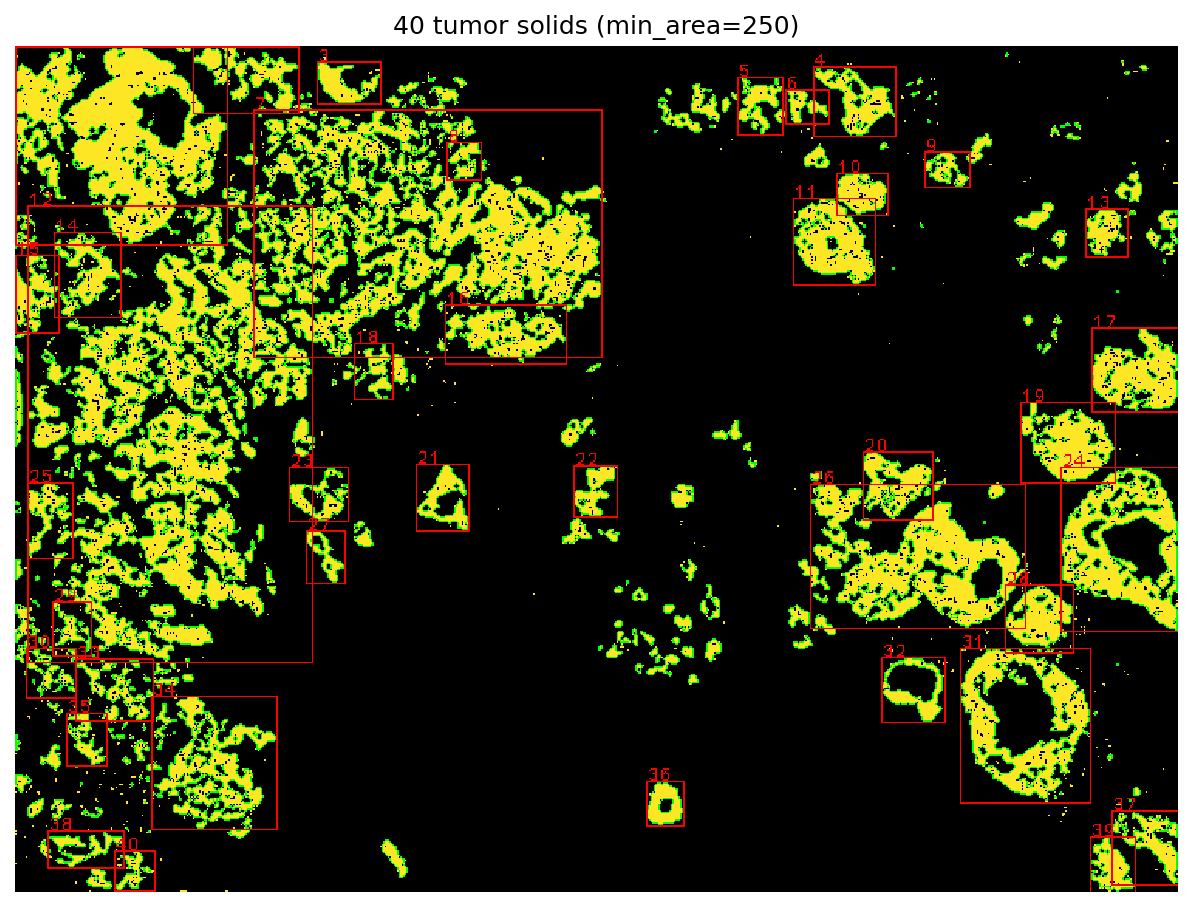

In [4]:
fig, ax = plt.subplots(figsize=(10, 8), dpi=150)
ax.imshow(cv2.cvtColor(solid.uns["individual_tumor_solid"], cv2.COLOR_BGR2RGB),
          interpolation="nearest")
ax.axis("off")
ax.set_title(f"{len(solid.obs)} tumor solids (min_area={MIN_AREA})")
plt.show()

## 3. Cell annotations

This dataset ships with a pathologist-annotated cell table (`cell.xlsx`). We join it to
the spatial coordinates and map the fine-grained clusters onto a broader cell-type
vocabulary.

**`BROAD_MAP` and `NON_TUMOR_TYPES` are specific to this dataset's cell annotations** —
adapt them when applying this notebook to a different dataset.

In [5]:
cell_ann_df = pd.read_excel("cell.xlsx")
cell_ann_df = cell_ann_df.set_index("Barcode")  # Barcode: 1-indexed cell id

adata_obs = adata.obs[["imagecol", "imagerow"]].copy()
adata_obs.index = adata_obs.index.astype(int)

cell_df = pd.concat([adata_obs, cell_ann_df[["Cluster"]]], axis=1)
cell_df = cell_df[["imagecol", "imagerow", "Cluster"]].dropna()
print(f"Total annotated cells: {len(cell_df)}")

BROAD_MAP = {
    "B_Cells":                  "B cells",
    "CD4+_T_Cells":             "CD4+ T cells",
    "CD8+_T_Cells":             "CD8+ T cells",
    "Macrophages_1":            "Macrophages / monocytes",
    "Macrophages_2":            "Macrophages / monocytes",
    "IRF7+_DCs":                "Dendritic cells",
    "LAMP3+_DCs":               "Dendritic cells",
    "Stromal":                  "Fibroblasts",
    "Endothelial":              "Endothelial cells",
    "Perivascular-Like":        "Endothelial cells",
    "Invasive_Tumor":           "Epithelial / tumor cells",
    "DCIS_1":                   "Epithelial / tumor cells",
    "DCIS_2":                   "Epithelial / tumor cells",
    "Prolif_Invasive_Tumor":    "Epithelial / tumor cells",
    "Myoepi_ACTA2+":            "Epithelial / tumor cells",
    "Myoepi_KRT15+":            "Epithelial / tumor cells",
    "Unlabeled":                "Other / unclassified",
    "Stromal_&_T_Cell_Hybrid":  "Other / unclassified",
    "T_Cell_&_Tumor_Hybrid":    "Other / unclassified",
    "Mast_Cells":               "Other / unclassified",
}

cell_df_broad = cell_df.copy()
cell_df_broad["BroadType"] = cell_df_broad["Cluster"].map(BROAD_MAP).fillna("Other / unclassified")

NON_TUMOR_TYPES = [
    "B cells", "CD4+ T cells", "CD8+ T cells", "Macrophages / monocytes",
    "Dendritic cells", "Fibroblasts", "Endothelial cells",
]

# scomv.cell.annotate_cells expects the cluster column to be named "Cluster"
broad_df = cell_df_broad[["imagecol", "imagerow", "BroadType"]].rename(columns={"BroadType": "Cluster"})
print(broad_df["Cluster"].value_counts())

Total annotated cells: 163565
Cluster
Epithelial / tumor cells    72560
Fibroblasts                 41401
Macrophages / monocytes     12781
Endothelial cells            9776
CD4+ T cells                 8431
CD8+ T cells                 6937
Other / unclassified         5908
B cells                      4979
Dendritic cells               792
Name: count, dtype: int64


## 4. Per-solid, per-cell-type polar histograms

For every solid and every non-tumor cell type, compute the polar (radius x angle)
histogram of that cell type's positions relative to the solid boundary.

In [6]:
from scomv.tumor_solid import compute_per_solid_polar_counts

BIN_SIZE = 10
MARGIN_BINS = 15
MIN_CELLS = 5

solid_broad_results = compute_per_solid_polar_counts(
    grid, solid, broad_df, NON_TUMOR_TYPES,
    bin_size=BIN_SIZE, margin_bins=MARGIN_BINS, min_cells=MIN_CELLS, cluster_col="Cluster",
)

print("Coverage (solids with enough cells of each type):")
for bt in NON_TUMOR_TYPES:
    print(f"  {bt:30s}: {len(solid_broad_results[bt]):3d} / {len(solid.obs)}")

Coverage (solids with enough cells of each type):
  B cells                       :  38 / 40
  CD4+ T cells                  :  39 / 40
  CD8+ T cells                  :  40 / 40
  Macrophages / monocytes       :  40 / 40
  Dendritic cells               :  25 / 40
  Fibroblasts                   :  40 / 40
  Endothelial cells             :  40 / 40


## 5. Uniformity

Convert each polar histogram into a single **uniformity** score per (solid, cell type,
distance bin): normalized Shannon entropy across angle bins (0 = concentrated in one
direction, 1 = spread evenly around the boundary), scaled down when a bin is backed by
few cells (via `n_ref`).

In [7]:
from scomv.tumor_solid import compute_uniformity

ALL_DIST_BINS = {
    "10-20µm": 16, "20-30µm": 17, "30-40µm": 18, "40-50µm": 19, "50-60µm": 20,
    "60-70µm": 21, "70-80µm": 22, "80-90µm": 23, "90-100µm": 24,
}

uniformity_mats, r_bar_mats = compute_uniformity(
    solid_broad_results, NON_TUMOR_TYPES, ALL_DIST_BINS, n_ref=12,
)
uniformity_mats["50-60µm"].head()

cell_type,B cells,CD4+ T cells,CD8+ T cells,Macrophages / monocytes,Dendritic cells,Fibroblasts,Endothelial cells
solid_id,,,,,,,
1,5.448755e-01,0.645027,5.784794e-01,0.706125,0.00000,0.795234,8.032161e-01
2,3.803432e-01,0.276963,6.059076e-02,0.157179,0.00000,0.733615,1.436514e-11
3,1.253792e-11,0.204694,1.293377e-11,0.163692,0.00000,0.640681,7.822667e-02
4,1.940808e-01,0.763062,4.326203e-01,0.589737,0.21258,0.722820,3.271290e-01
5,3.711341e-01,0.603244,6.131034e-01,0.499541,0.00000,0.573706,3.416984e-01


## 6. Distance-weighted uniformity

Collapse the distance-bin dimension into a single feature matrix, weighting closer bins
more heavily (an inverse-square-root falloff, normalized to 1.0 at 10-20µm).

In [8]:
from scomv.tumor_solid import distance_weighted_mean

BIN_WEIGHTS = {
    "10-20µm": 1.0,
    "20-30µm": np.sqrt(15 / 25),
    "30-40µm": np.sqrt(15 / 35),
    "40-50µm": np.sqrt(15 / 45),
    "50-60µm": np.sqrt(15 / 55),
    "60-70µm": np.sqrt(15 / 65),
    "70-80µm": np.sqrt(15 / 75),
    "80-90µm": np.sqrt(15 / 85),
    "90-100µm": np.sqrt(15 / 95),
}

feat_dist_weighted = distance_weighted_mean(uniformity_mats, BIN_WEIGHTS)
feat_dist_weighted.head()

cell_type,B cells,CD4+ T cells,CD8+ T cells,Macrophages / monocytes,Dendritic cells,Fibroblasts,Endothelial cells
solid_id,,,,,,,
1,0.461684,0.629128,0.555098,0.757210,6.703705e-12,0.838993,0.639930
2,0.172093,0.130362,0.054110,0.408061,0.000000e+00,0.599326,0.229037
3,0.045173,0.071510,0.024661,0.199615,0.000000e+00,0.379320,0.104416
4,0.183194,0.485985,0.451055,0.514991,2.942242e-02,0.703797,0.342646
5,0.116276,0.493264,0.555507,0.526812,6.533510e-03,0.635405,0.187986


## 7. Ward clustering

Cluster solids by their distance-weighted uniformity profile, then relabel clusters so
"cluster 0" always has the highest mean CD8+ T cell uniformity — purely for consistent,
readable plots across reruns.

In [9]:
from scomv.tumor_solid import ward_cluster, remap_clusters_by_reference

N_CLUSTERS = 5

labels_w, Z_ward = ward_cluster(feat_dist_weighted, n_clusters=N_CLUSTERS)
labels_w, cluster_remap = remap_clusters_by_reference(
    labels_w, feat_dist_weighted, ref_col="CD8+ T cells", ascending=False,
)

print("Cluster sizes:")
for k in range(N_CLUSTERS):
    solids_in_k = list(feat_dist_weighted.index[labels_w == k])
    print(f"  c{k} (n={len(solids_in_k)}): {solids_in_k}")

Cluster sizes:
  c0 (n=1): [12]
  c1 (n=4): [4, 5, 6, 38]
  c2 (n=6): [1, 7, 14, 26, 31, 32]
  c3 (n=15): [2, 15, 16, 17, 19, 20, 21, 23, 24, 25, 27, 28, 33, 34, 35]
  c4 (n=14): [3, 8, 9, 10, 11, 13, 18, 22, 29, 30, 36, 37, 39, 40]


## 8. Visualizing the clustering

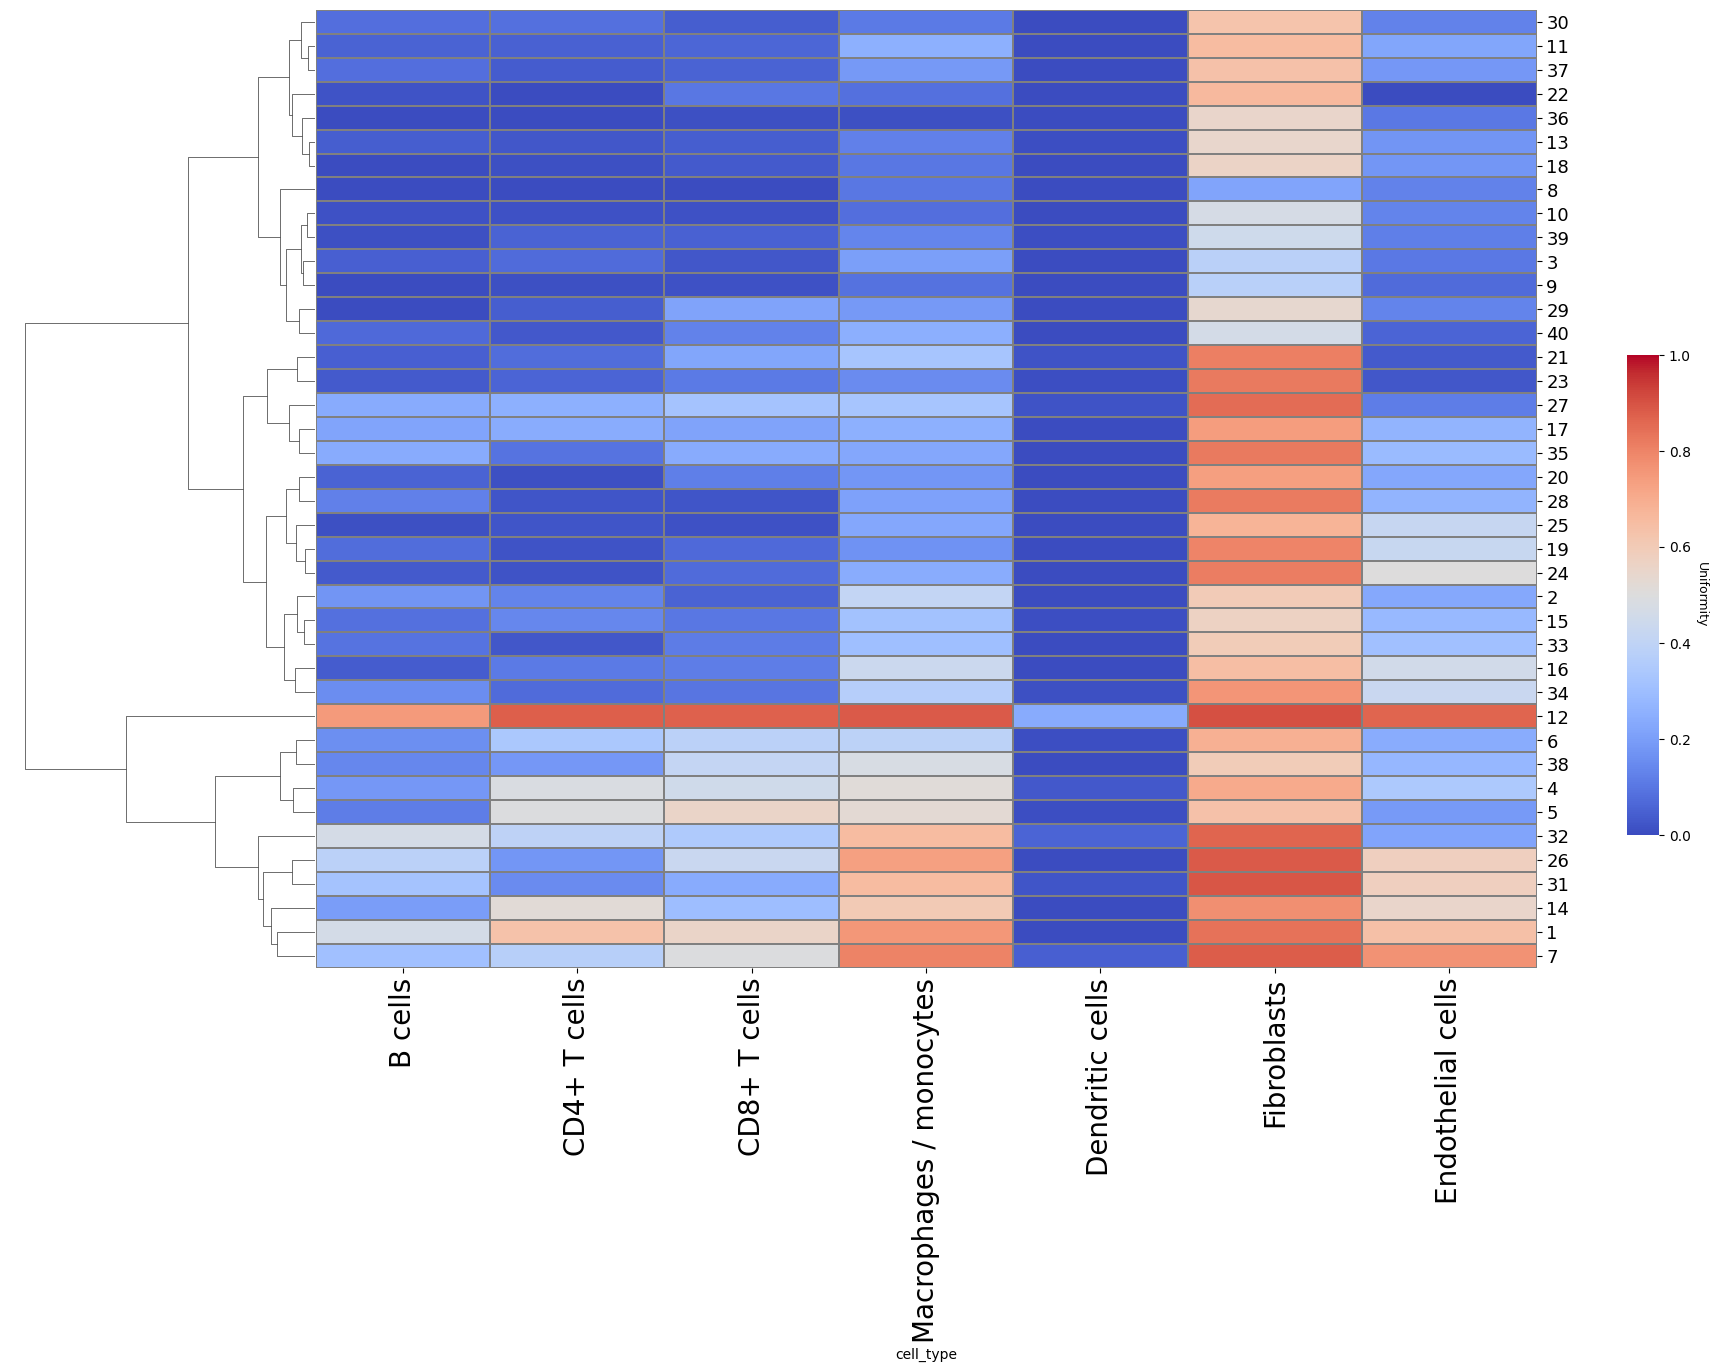

In [10]:
from scomv.tumor_solid import plot_uniformity_heatmap

plot_uniformity_heatmap(feat_dist_weighted, Z_ward)
plt.show()

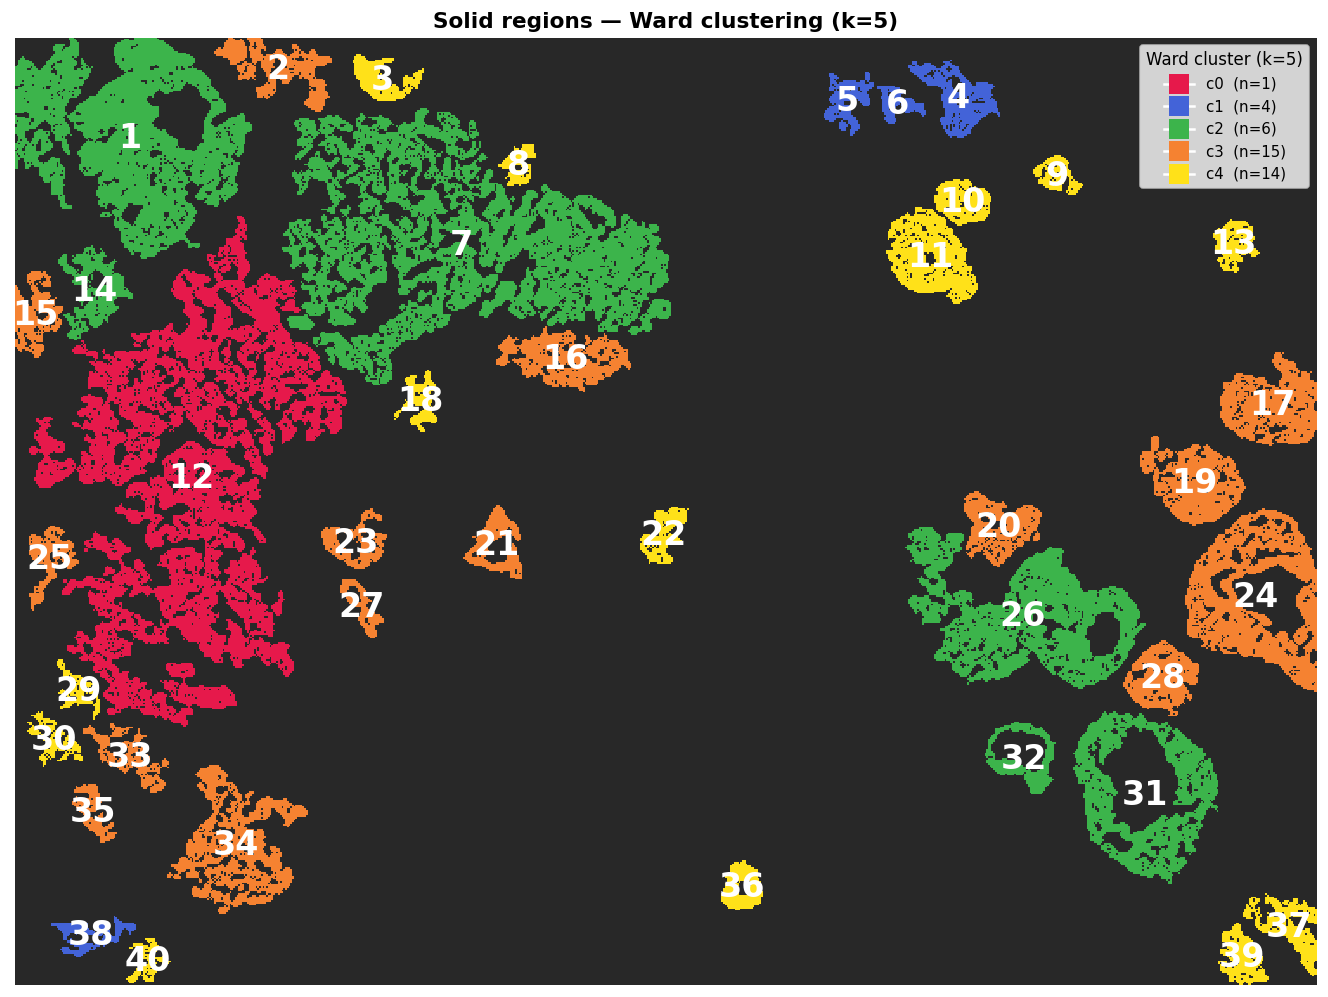

In [11]:
from scomv.tumor_solid import plot_cluster_map

cluster_of_solid = dict(zip(feat_dist_weighted.index, labels_w))

ax, cluster_img = plot_cluster_map(
    labels, solid.obs, cluster_of_solid,
    n_clusters=N_CLUSTERS,
    title=f"Solid regions — Ward clustering (k={N_CLUSTERS})",
    legend_title=f"Ward cluster (k={N_CLUSTERS})",
)
plt.show()

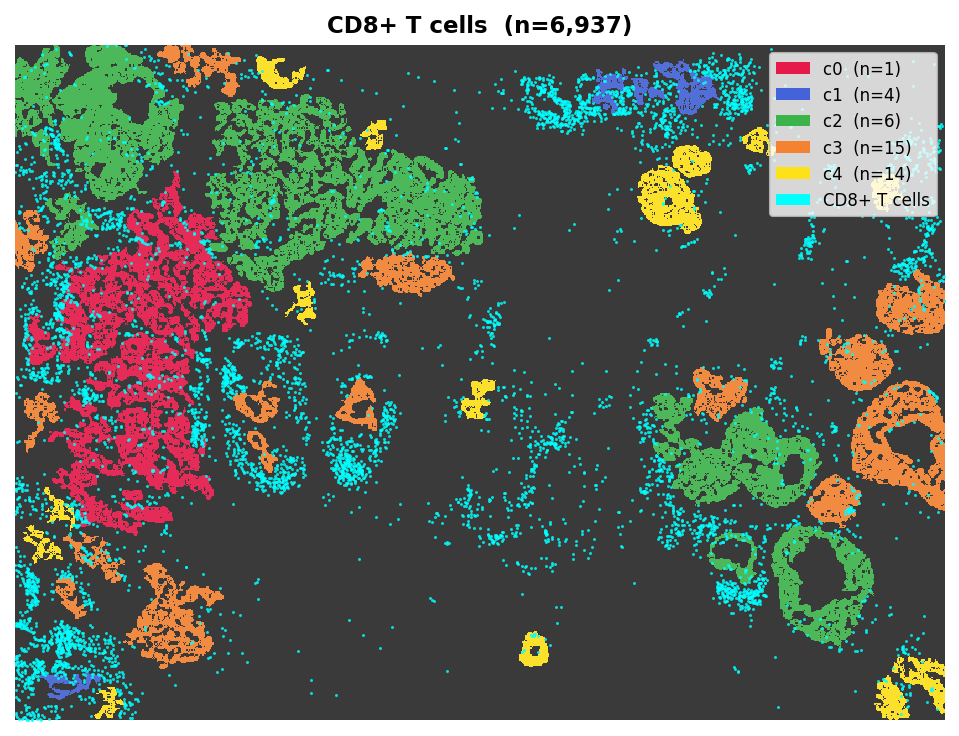

In [12]:
from functools import partial
from scomv.tumor_solid import plot_cell_type_over_clusters

cluster_sizes = pd.Series(labels_w).value_counts().to_dict()

# Bind everything except the cell type name, so each call below is a
# one-liner: "which cell type do I want to see on the cluster map?"
show_celltype = partial(
    plot_cell_type_over_clusters,
    cell_df=cell_df_broad,
    cluster_img=cluster_img,
    origin=(adata.obs.imagecol.min(), adata.obs.imagerow.min()),
    cluster_sizes=cluster_sizes,
    cluster_col="BroadType",
)

show_celltype("CD8+ T cells")
plt.show()

/Users/nomura/SpatialCompassV_2/src/scomv/tumor_solid.py:848: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


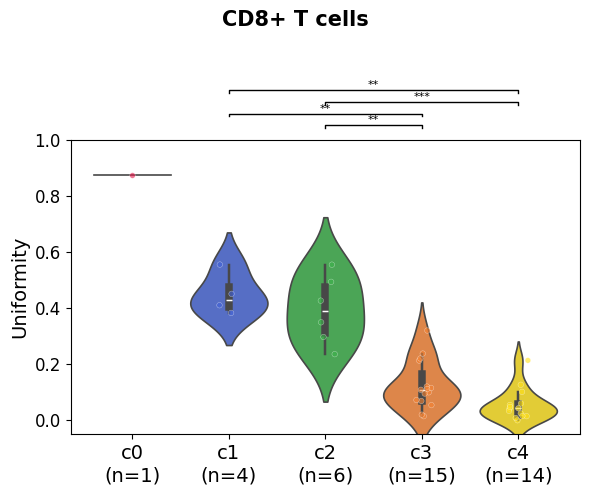

In [13]:
from scomv.tumor_solid import plot_uniformity_by_cluster

# Same idea: pass a cell type name, get a violin/strip plot with significance bars.
plot_uniformity_by_cluster("CD8+ T cells", feat_dist_weighted, labels_w)
plt.show()

## 9. Comparing two tumors (or two clusters)

Every function below takes a **tumor (solid) number**, or a **list of tumor numbers**
(e.g. all solids in one Ward cluster) — the same numbers labeled in the `plot_cluster_map`
figure above.

Set `SOLID_A` / `SOLID_B` once here; everything below re-runs for whichever pair you
choose.

In [14]:
# The tumor numbers being compared. Edit these to compare a different pair.
SOLID_A = 1
SOLID_B = 12

### 9a. Expression fold factor

Correct for a systematic difference in total expression between the two tumors before
comparing their gene-level uniformity.

In [15]:
from scomv.tumor_solid import compute_expression_fold_factor

k = compute_expression_fold_factor(grid, solid, SOLID_A, SOLID_B)
print(f"Fold factor k = median(expr_{SOLID_B} / expr_{SOLID_A}): {k:.3f}")

Fold factor k = median(expr_12 / expr_1): 3.533


### 9b. Gene-level uniformity: 2D comparison

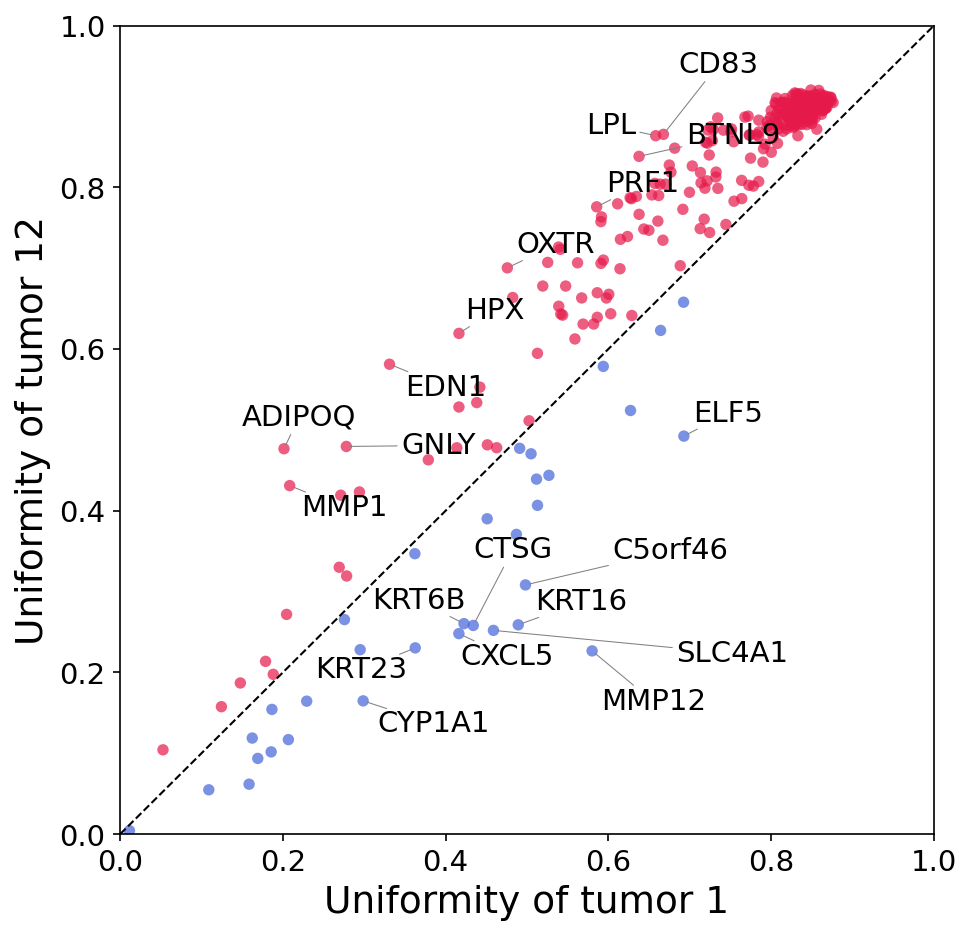

In [16]:
from scomv.tumor_solid import compute_gene_uniformity_pair, plot_gene_uniformity_scatter

# correct_expression=True (default) applies the fold factor above automatically.
wu_a, wu_b, k = compute_gene_uniformity_pair(
    grid, solid, SOLID_A, SOLID_B, dist_bins=ALL_DIST_BINS,
)

ax, ann_genes = plot_gene_uniformity_scatter(
    wu_a, wu_b, BIN_WEIGHTS,
    label_a=f"tumor {SOLID_A}", label_b=f"tumor {SOLID_B}", n_annotate=10,
)
plt.show()

### 9c. Cluster-level comparison

The same functions work unchanged when comparing groups of several solids (e.g. two
Ward clusters) instead of single tumors — just pass a list of solid numbers.

Cluster-level fold factor k: 0.250


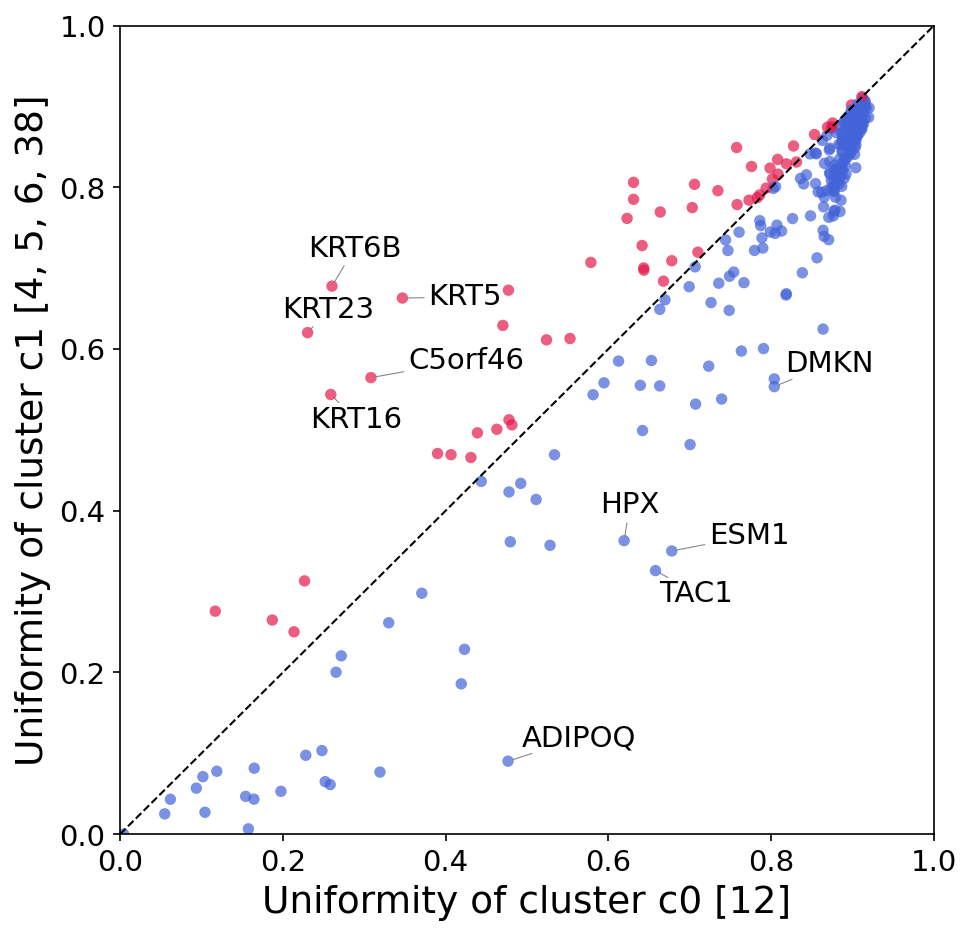

In [17]:
CLUSTER_A = list(feat_dist_weighted.index[labels_w == 0])
CLUSTER_B = list(feat_dist_weighted.index[labels_w == 1])

wu_c0, wu_c1, k_cluster = compute_gene_uniformity_pair(
    grid, solid, CLUSTER_A, CLUSTER_B, dist_bins=ALL_DIST_BINS,
)
print(f"Cluster-level fold factor k: {k_cluster:.3f}")

ax, _ = plot_gene_uniformity_scatter(
    wu_c0, wu_c1, BIN_WEIGHTS,
    label_a=f"cluster c0 {CLUSTER_A}", label_b=f"cluster c1 {CLUSTER_B}", n_annotate=5,
)
plt.show()

## 10. Differential expression (DEG)

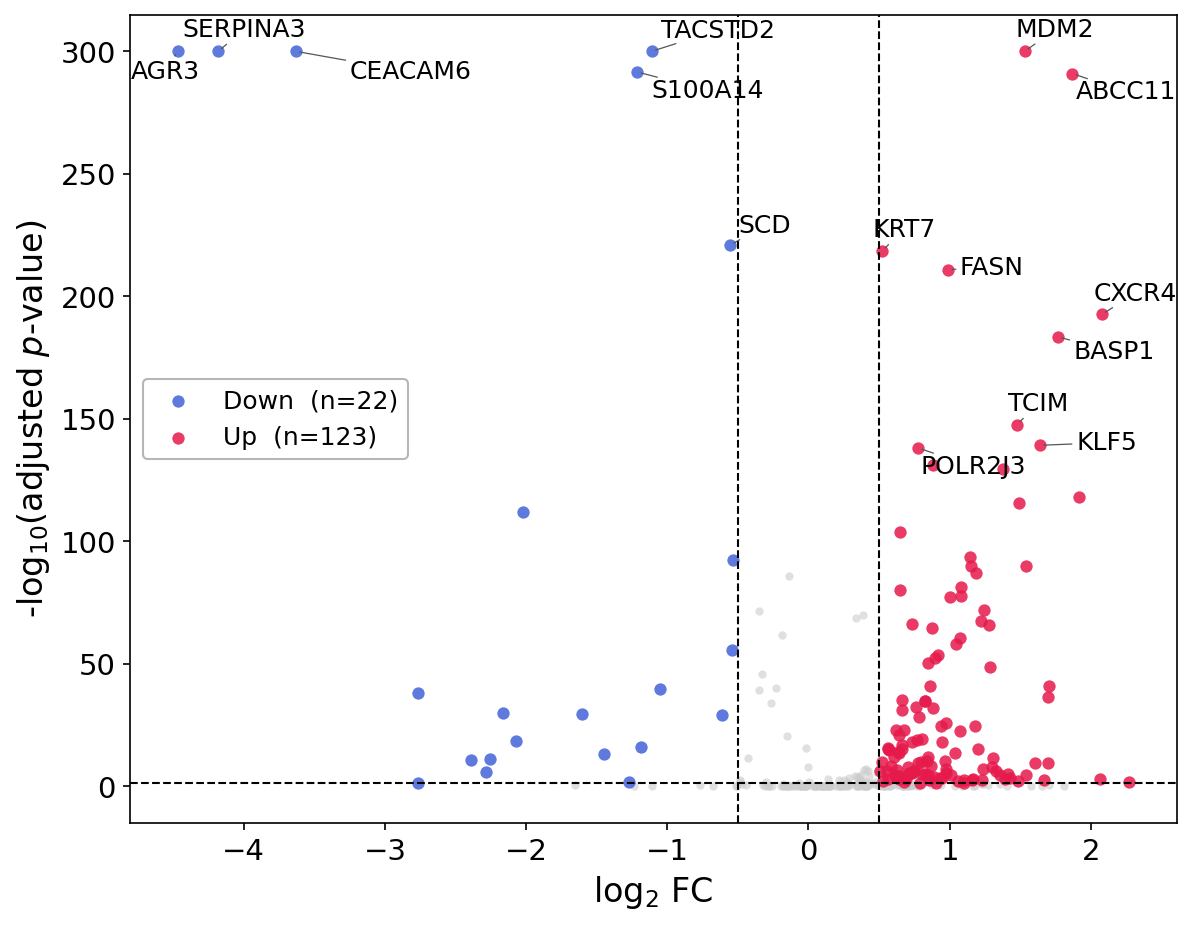

Up in tumor12: 123 genes
Down in tumor12: 22 genes


In [18]:
from scomv.tumor_solid import assign_solid_ids, compute_deg_between_solid_groups, plot_deg_volcano

# solid id per cell, aligned to adata.obs.index
cell_solid_ids = pd.Series(assign_solid_ids(adata.obs, labels), index=adata.obs.index)

deg_df = compute_deg_between_solid_groups(
    adata, cell_solid_ids, SOLID_A, SOLID_B,
    label_a=f"tumor{SOLID_A}", label_b=f"tumor{SOLID_B}",
)

ax, genes_up, genes_down = plot_deg_volcano(deg_df, sig_padj=0.05, sig_lfc=0.5, n_annotate=15)
plt.show()

print(f"Up in tumor{SOLID_B}: {len(genes_up)} genes")
print(f"Down in tumor{SOLID_B}: {len(genes_down)} genes")

## 11. Pathway enrichment (optional)

Requires network access (calls the Enrichr web API) and the optional `gseapy` package.

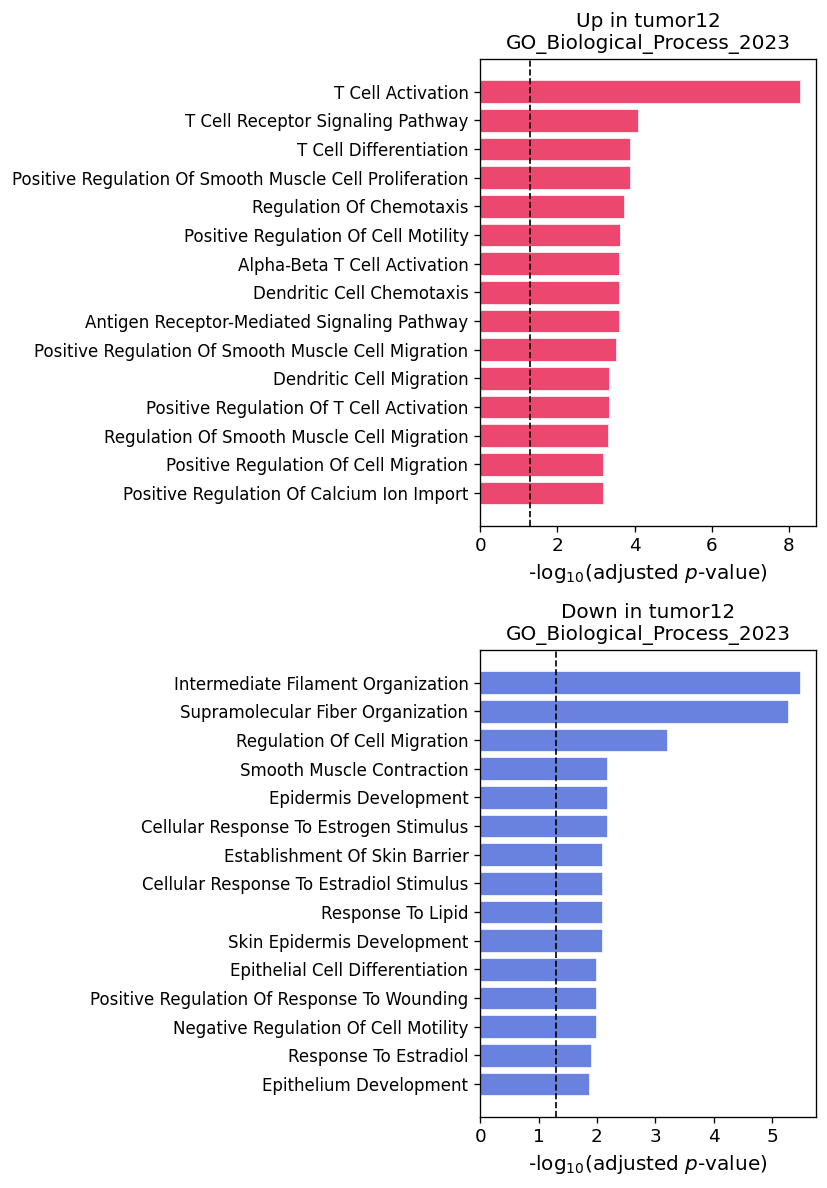

In [20]:
from scomv.tumor_solid import run_pathway_enrichment, plot_pathway_enrichment

GENE_SETS = ["GO_Biological_Process_2023"]

gene_lists = {f"Up in tumor{SOLID_B}": genes_up, f"Down in tumor{SOLID_B}": genes_down}
enrich_results = run_pathway_enrichment(gene_lists, gene_sets=GENE_SETS)

plot_pathway_enrichment(enrich_results, gene_sets=GENE_SETS, top_n=15)
plt.show()